In [14]:
from glob import glob
from votekit.cvr_loaders import load_scottish
import numpy as np
import matplotlib.pyplot as plt

SCOT_ELEX_PATH = "/Users/cdonnay/PycharmProjects/scot-elex"
b_bloc_parties = ["Scottish National Party (SNP)", "Green (Gr)"]
bloc_order = "AB"

import sys
sys.path.insert(0, '../minimize_l1')

from swap_distance import dist_profile_to_solid, symmetric_dist_profile_to_solid
# all_files = glob(f"{SCOT_ELEX_PATH}/*_cands/*.csv")
# for file_name in all_files:
#     print(file_name)

In [2]:
def bubble_plot_integer(ax, 
data, 
labels, 
colors, 
title, 
bloc_order, 
marker =".", 
size = 1000):
    # create figure
    # fig, ax = plt.subplots() #plt.figure()
    
    x_max = int(max(max(vector) for vector in data))
    bin_min = 0
    bin_max = x_max
    bins = np.arange(bin_min-.5, bin_max+1.5, 1)
    
    for j, vector in enumerate(data):
        x = [i for i in range(x_max+1)] # x=0,...,x_max
        y = [j+1]*len(x) # put each vector at a different height
        
        bin_heights, bin_edges = np.histogram(vector, bins = bins,density=True)
        circle_areas = [size*bin_heights[i] for i in range(x_max+1)]
        ax.scatter(x, y, s=circle_areas, alpha=1, color = colors[j], label = None, edgecolors='black', marker=marker)

    # Add labels and title
    ax.set_xlabel(f'Distance to solid ballot ({bloc_order})')
    ax.set_xticks([i for i in range(x_max+1)])
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_yticks([i+1 for i in range(len(data))], labels)
    ax.set_xlim((-2, x_max+2))
    ax.set_ylim((0.5, len(data)+.5))
    ax.set_title(title)
    
    return ax

# Variance
Compute the swap vector of each election, take the variance.

In [22]:
all_files = glob(f"{SCOT_ELEX_PATH}/*_cands/*.csv")

variance_dict = {}
no_b_bloc_parties = 0

for file_name in all_files:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}

    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

    if all(party not in set(cand_to_party.values()) for party in b_bloc_parties):
        no_b_bloc_parties +=1
        print(f"no b bloc parties: {file_name.split('/')[-1]}")
        continue


    swap_vector = dist_profile_to_solid(profile, cand_to_bloc, bloc_order)

    # normalize by max swap size
    max_swap_size = np.prod(list(bloc_to_cand_num.values()))
    
    variance = np.var(swap_vector) / max_swap_size

    variance_dict[file_name] = variance
    

print(f"This many elections do not have either B bloc party: {no_b_bloc_parties}")

no b bloc parties: eilean_siar_2022_ward3.csv
no b bloc parties: shetland_2012_ward2.csv
no b bloc parties: shetland_2012_ward3.csv
no b bloc parties: orkney_2017_ward2.csv
no b bloc parties: shetland_2022_ward6.csv
no b bloc parties: shetland_2012_ward1.csv
no b bloc parties: orkney_2022_ward6.csv
no b bloc parties: shetland_2017_ward1.csv
no b bloc parties: shetland_2017_ward7.csv
no b bloc parties: shetland_2022_ward5.csv
no b bloc parties: shetland_2017_ward4.csv
no b bloc parties: shetland_2012_ward5.csv
no b bloc parties: eilean_siar_2017_ward4.csv
no b bloc parties: orkney_2012_ward6.csv
no b bloc parties: shetland_2017_ward2.csv
no b bloc parties: shetland_2017_ward6.csv
no b bloc parties: shetland_2012_ward4.csv
no b bloc parties: eilean_siar_2017_ward5.csv
no b bloc parties: shetland_2017_ward3.csv
no b bloc parties: orkney_2017_ward6.csv
no b bloc parties: orkney_2017_ward1.csv
no b bloc parties: orkney_2012_ward4.csv
This many elections do not have either B bloc party: 22


In [23]:
# print sorted by variance, high variance means polarized
sorted_elections_by_variance_high_low =  sorted(list(variance_dict.keys()), 
        key = lambda x: variance_dict[x],
        reverse=True, )

In [24]:
print("Top 5 most polarized elections, variance")
for e in sorted_elections_by_variance_high_low[:5]:
    print (e.split("/")[-1], round(variance_dict[e], 4))

Top 5 most polarized elections, variance
glasgow_2017_ward19.csv 2.1662
glasgow_2017_ward1.csv 2.166
glasgow_2022_ward18.csv 2.1306
edinburgh_2022_ward11.csv 2.0731
glasgow_2022_ward14.csv 2.0553


glasgow_2017_ward19.csv {'A': 8, 'B': 4}
glasgow_2017_ward1.csv {'A': 8, 'B': 4}
glasgow_2022_ward18.csv {'A': 7, 'B': 4}
edinburgh_2022_ward11.csv {'A': 10, 'B': 3}
glasgow_2022_ward14.csv {'A': 6, 'B': 4}


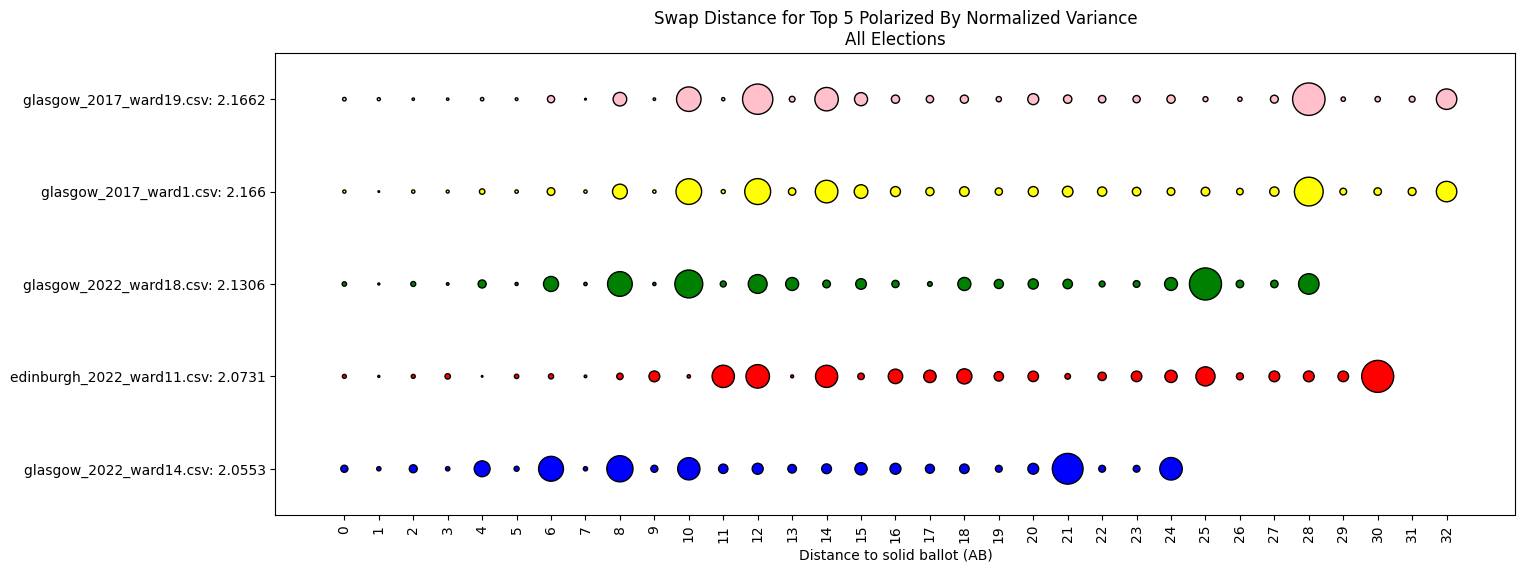

<Figure size 640x480 with 0 Axes>

In [33]:
top_5_polarized_var = sorted_elections_by_variance_high_low[:5]

swap_vectors = []
for file in top_5_polarized_var:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
            else "A" for c in cand_list}
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

    print(file.split("/")[-1], bloc_to_cand_num)
    swap_vectors.append(dist_profile_to_solid(profile, cand_to_bloc, bloc_order))

fig, ax = plt.subplots(figsize=(16,6))
ax = bubble_plot_integer(ax, 
    swap_vectors[::-1], 
    [f"{file.split('/')[-1]}: {round(variance_dict[file],4)}" for file in top_5_polarized_var][::-1],
    ["blue", "red", "green", "yellow", "pink"],
    "Swap Distance for Top 5 Polarized By Normalized Variance\nAll Elections",
    bloc_order,
    size = 10000)

plt.show()
plt.clf()


In [30]:
print("Bottom 5 most polarized elections, variance")
for e in sorted_elections_by_variance_high_low[-5:]:
    print (e.split("/")[-1], round(variance_dict[e], 4))

Bottom 5 most polarized elections, variance
eilean_siar_2022_ward4.csv 0.2822
dumgal_2012_ward1.csv 0.2544
eilean_siar_2022_ward5.csv 0.2433
sc_borders_2022_ward10.csv 0.2433
orkney_2012_ward5.csv 0.2415


eilean_siar_2022_ward4.csv {'A': 2, 'B': 1}
dumgal_2012_ward1.csv {'A': 3, 'B': 1}
eilean_siar_2022_ward5.csv {'A': 3, 'B': 1}
sc_borders_2022_ward10.csv {'A': 5, 'B': 1}
orkney_2012_ward5.csv {'A': 6, 'B': 1}


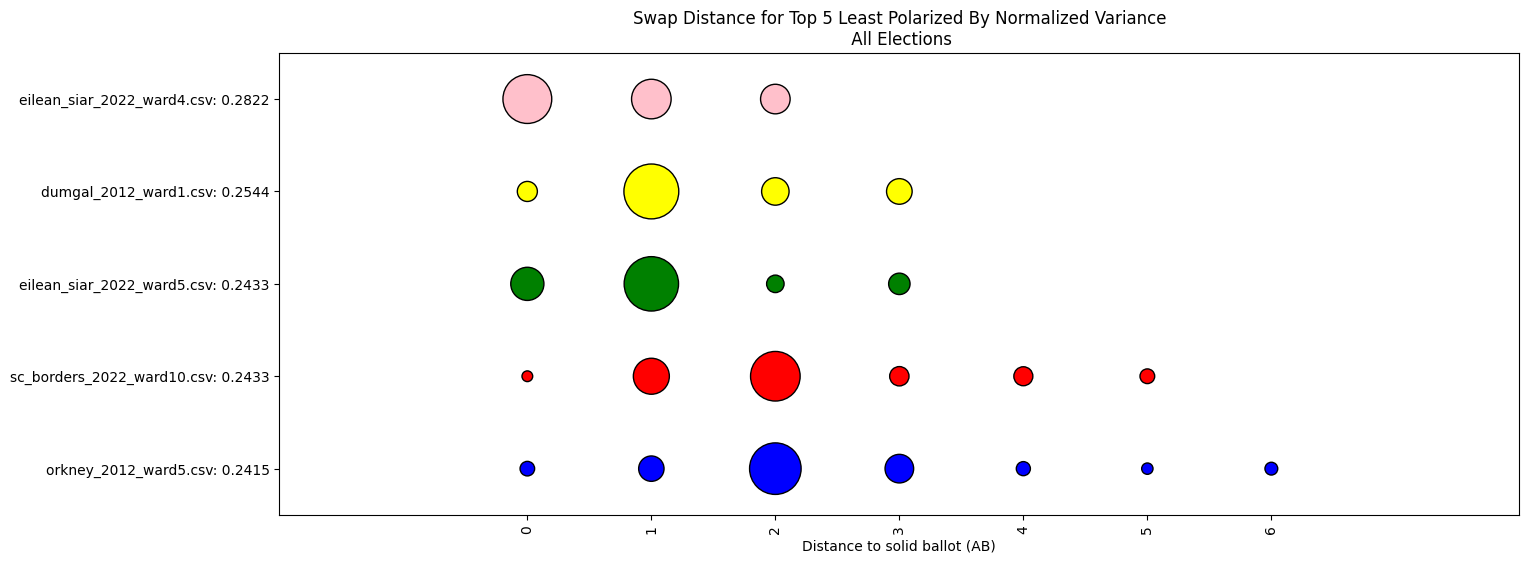

<Figure size 640x480 with 0 Axes>

In [32]:
bottom_5_polarized_var = sorted_elections_by_variance_high_low[-5:]

swap_vectors = []
for file in bottom_5_polarized_var:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
            else "A" for c in cand_list}
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

    print(file.split("/")[-1], bloc_to_cand_num)
    swap_vectors.append(dist_profile_to_solid(profile, cand_to_bloc, bloc_order))

fig, ax = plt.subplots(figsize=(16,6))
ax = bubble_plot_integer(ax, 
    swap_vectors[::-1], 
    [f"{file.split('/')[-1]}: {round(variance_dict[file],4)}" for file in bottom_5_polarized_var][::-1],
    ["blue", "red", "green", "yellow", "pink"],
    "Swap Distance for Top 5 Least Polarized By Normalized Variance\n All Elections",
    bloc_order,
    size = 10000)

plt.show()
plt.clf()


In [ ]:
# repeat the least polarized requiring that there be at least 2 candidates per bloc

In [34]:
all_files = glob(f"{SCOT_ELEX_PATH}/*_cands/*.csv")

variance_dict = {}
no_b_bloc_parties = 0

for file_name in all_files:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}

    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

    # need at least 2 per bloc
    if bloc_to_cand_num["A"] <2 or bloc_to_cand_num["B"] <2:
        continue

    swap_vector = dist_profile_to_solid(profile, cand_to_bloc, bloc_order)

    # normalize by max swap size
    max_swap_size = np.prod(list(bloc_to_cand_num.values()))
    
    variance = np.var(swap_vector) / max_swap_size

    variance_dict[file_name] = variance

In [35]:
sorted_2_cand_elections_by_variance_high_low =  sorted(list(variance_dict.keys()), 
        key = lambda x: variance_dict[x],
        reverse=True, )

argyll_bute_2012_ward2.csv {'A': 5, 'B': 2}
eilean_siar_2012_ward3.csv {'A': 2, 'B': 2}
aberdeen_2012_ward11.csv {'A': 4, 'B': 2}
aberdeenshire_2012_ward16.csv {'A': 3, 'B': 2}
sc_borders_2012_ward11.csv {'A': 5, 'B': 2}


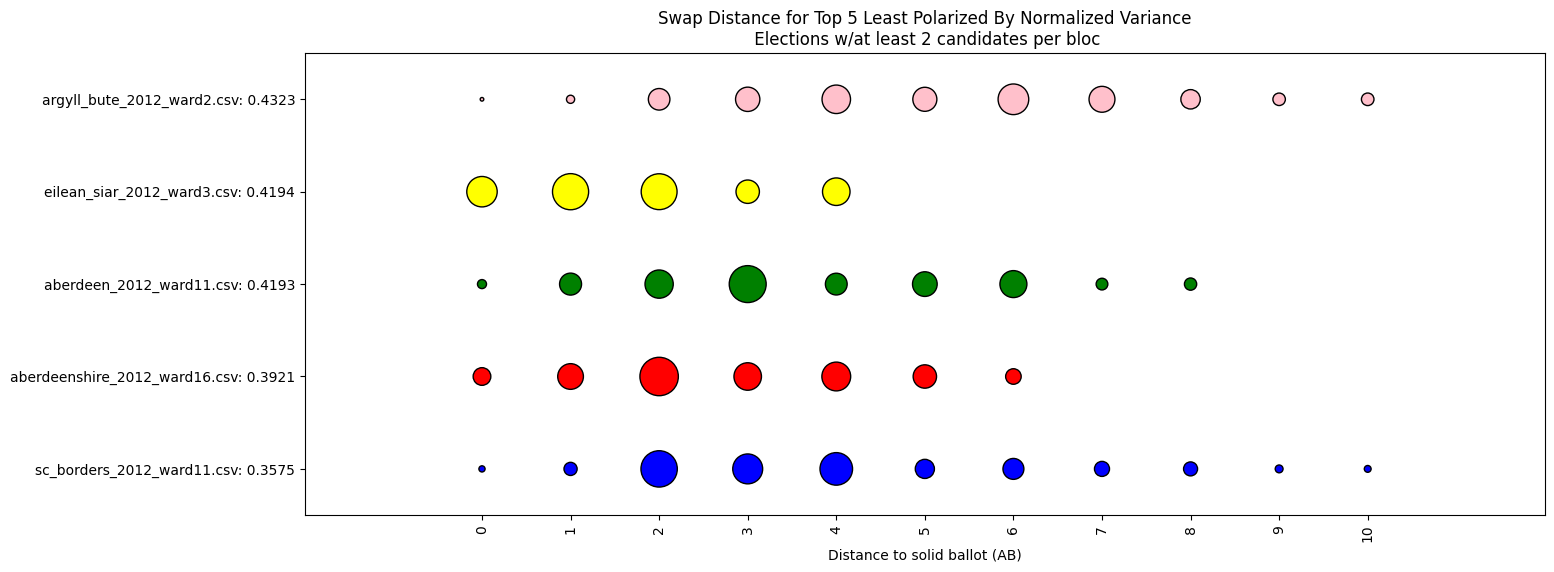

<Figure size 640x480 with 0 Axes>

In [36]:
bottom_5_polarized_var = sorted_2_cand_elections_by_variance_high_low[-5:]

swap_vectors = []
for file in bottom_5_polarized_var:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
            else "A" for c in cand_list}
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

    print(file.split("/")[-1], bloc_to_cand_num)
    swap_vectors.append(dist_profile_to_solid(profile, cand_to_bloc, bloc_order))

fig, ax = plt.subplots(figsize=(16,6))
ax = bubble_plot_integer(ax, 
    swap_vectors[::-1], 
    [f"{file.split('/')[-1]}: {round(variance_dict[file],4)}" for file in bottom_5_polarized_var][::-1],
    ["blue", "red", "green", "yellow", "pink"],
    "Swap Distance for Top 5 Least Polarized By Normalized Variance\n Elections w/at least 2 candidates per bloc",
    bloc_order,
    size = 10000)

plt.show()
plt.clf()


In [42]:
# 7 candidates is most frequent, perform analysis on that
all_files = glob(f"{SCOT_ELEX_PATH}/*_cands/*.csv")

variance_dict = {}
no_b_bloc_parties = 0

for file_name in all_files:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}

    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

    # need at 7 candidates and 2 per bloc
    if len(cand_list) !=7 or all(party not in set(cand_to_party.values()) for party in b_bloc_parties) or bloc_to_cand_num["A"] <2 or bloc_to_cand_num["B"] <2:
        continue

    swap_vector = dist_profile_to_solid(profile, cand_to_bloc, bloc_order)

    # normalize by max swap size
    max_swap_size = np.prod(list(bloc_to_cand_num.values()))
    
    variance = np.var(swap_vector) / max_swap_size

    variance_dict[file_name] = variance

In [43]:
sorted_7_cand_elections_by_variance_high_low =  sorted(list(variance_dict.keys()), 
        key = lambda x: variance_dict[x],
        reverse=True, )

edinburgh_2012_ward2.csv {'A': 5, 'B': 2}
edinburgh_2012_ward1.csv {'A': 5, 'B': 2}
edinburgh_2012_ward10.csv {'A': 5, 'B': 2}
argyll_bute_2012_ward2.csv {'A': 5, 'B': 2}
sc_borders_2012_ward11.csv {'A': 5, 'B': 2}


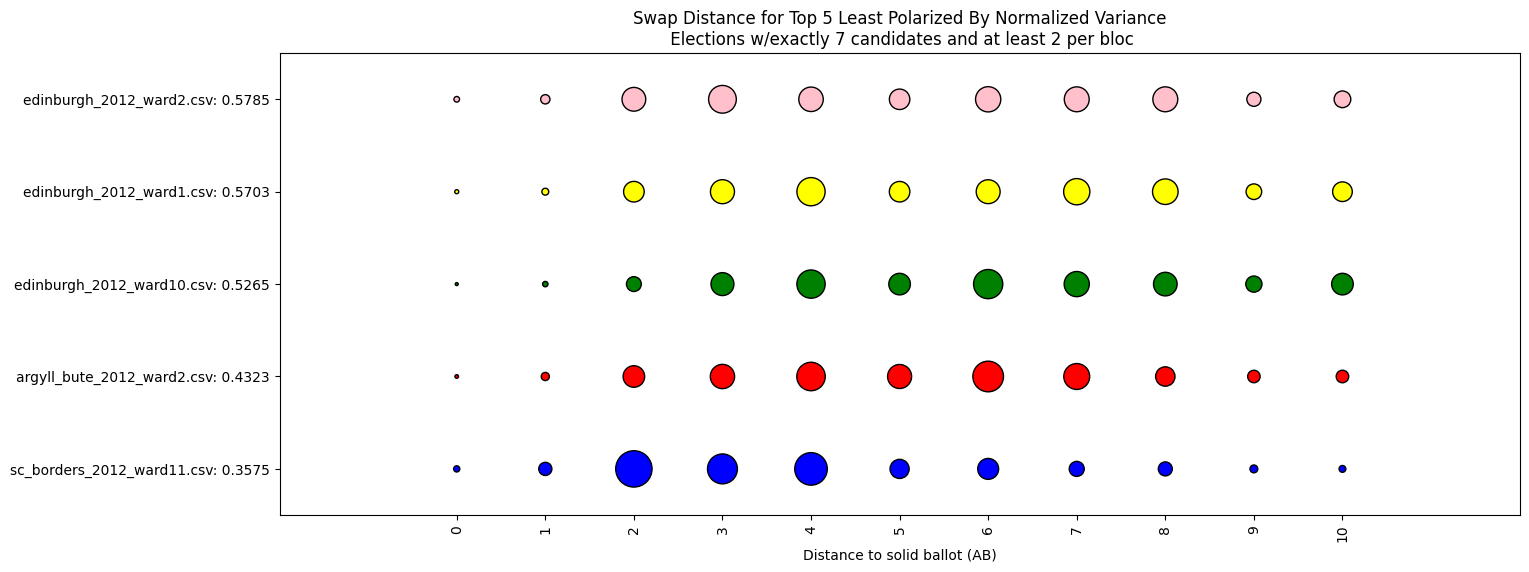

<Figure size 640x480 with 0 Axes>

In [44]:
bottom_5_polarized_var = sorted_7_cand_elections_by_variance_high_low[-5:]

swap_vectors = []
for file in bottom_5_polarized_var:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
            else "A" for c in cand_list}
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

    print(file.split("/")[-1], bloc_to_cand_num)
    swap_vectors.append(dist_profile_to_solid(profile, cand_to_bloc, bloc_order))

fig, ax = plt.subplots(figsize=(16,6))
ax = bubble_plot_integer(ax, 
    swap_vectors[::-1], 
    [f"{file.split('/')[-1]}: {round(variance_dict[file],4)}" for file in bottom_5_polarized_var][::-1],
    ["blue", "red", "green", "yellow", "pink"],
    "Swap Distance for Top 5 Least Polarized By Normalized Variance\n Elections w/exactly 7 candidates and at least 2 per bloc",
    bloc_order,
    size = 10000)

plt.show()
plt.clf()


west_dunbartonshire_2022_ward6.csv {'A': 4, 'B': 3}
west_lothian_2017_ward7.csv {'A': 4, 'B': 3}
clackmannanshire_2022_ward3.csv {'A': 4, 'B': 3}
west_lothian_2012_ward4.csv {'A': 4, 'B': 3}
west_lothian_2012_ward5.csv {'A': 4, 'B': 3}


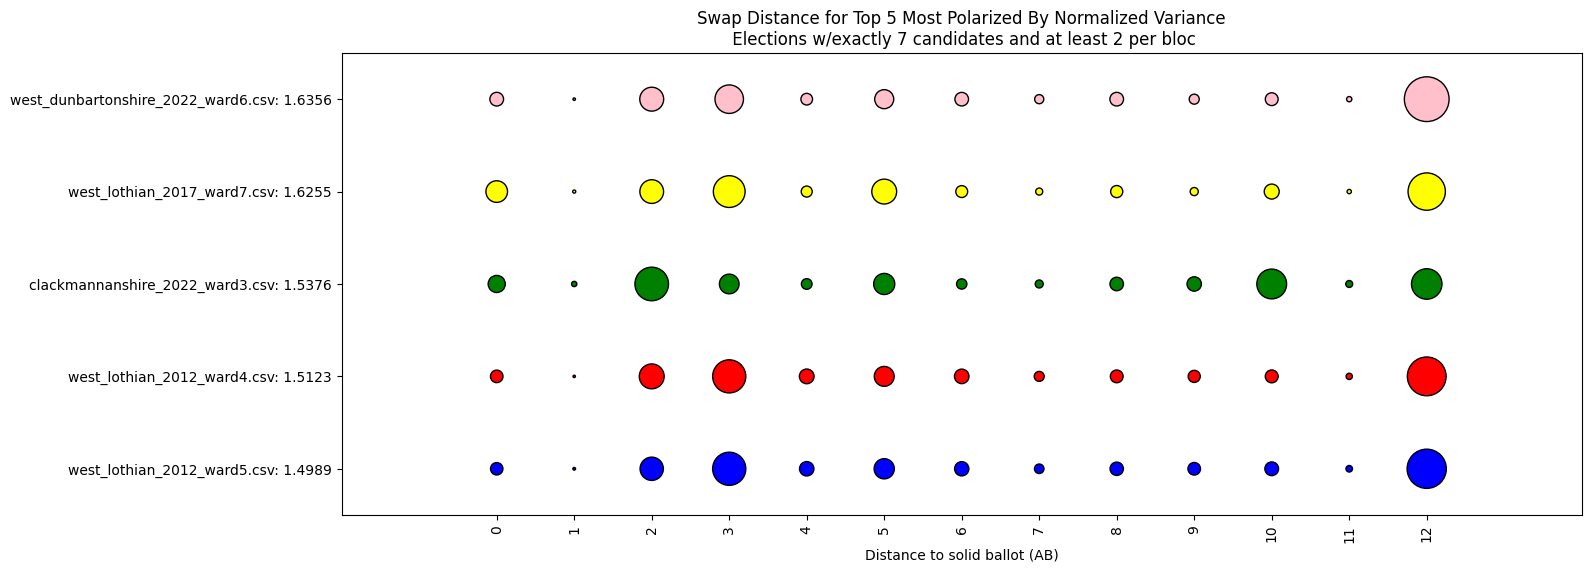

<Figure size 640x480 with 0 Axes>

In [46]:
top_5_polarized_var = sorted_7_cand_elections_by_variance_high_low[:5]

swap_vectors = []
for file in top_5_polarized_var:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
            else "A" for c in cand_list}
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                    "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}

    print(file.split("/")[-1], bloc_to_cand_num)
    swap_vectors.append(dist_profile_to_solid(profile, cand_to_bloc, bloc_order))

fig, ax = plt.subplots(figsize=(16,6))
ax = bubble_plot_integer(ax, 
    swap_vectors[::-1], 
    [f"{file.split('/')[-1]}: {round(variance_dict[file],4)}" for file in top_5_polarized_var][::-1],
    ["blue", "red", "green", "yellow", "pink"],
    "Swap Distance for Top 5 Most Polarized By Normalized Variance\n Elections w/exactly 7 candidates and at least 2 per bloc",
    bloc_order,
    size = 10000)

plt.show()
plt.clf()


# Symmetric Swap Vector
Instead of the normal swap vector and having to fix A over B, try taking a symmetric swap vector.
That is, record the minimum of swap to A over B and B over A.

In [6]:
all_files = glob(f"{SCOT_ELEX_PATH}/*_cands/*.csv")

sym_variance_dict = {}
no_b_bloc_parties = 0

for file_name in all_files:
    profile, num_seats, cand_list, cand_to_party, ward_name = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}

    if all(party not in set(cand_to_party.values()) for party in b_bloc_parties):
        no_b_bloc_parties +=1
        print(f"no b bloc parties: {file_name.split('/')[-1]}")
        continue


    swap_vector = symmetric_dist_profile_to_solid(profile, cand_to_bloc, bloc_order)

    variance = np.var(swap_vector)

    sym_variance_dict[file_name] = variance
    

print(f"This many elections do not have either B bloc party: {no_b_bloc_parties}")



no b bloc parties: eilean_siar_2022_ward3.csv
no b bloc parties: shetland_2012_ward2.csv
no b bloc parties: shetland_2012_ward3.csv
no b bloc parties: orkney_2017_ward2.csv
no b bloc parties: shetland_2022_ward6.csv
no b bloc parties: shetland_2012_ward1.csv
no b bloc parties: orkney_2022_ward6.csv
no b bloc parties: shetland_2017_ward1.csv
no b bloc parties: shetland_2017_ward7.csv
no b bloc parties: shetland_2022_ward5.csv
no b bloc parties: shetland_2017_ward4.csv
no b bloc parties: shetland_2012_ward5.csv
no b bloc parties: eilean_siar_2017_ward4.csv
no b bloc parties: orkney_2012_ward6.csv
no b bloc parties: shetland_2017_ward2.csv
no b bloc parties: shetland_2017_ward6.csv
no b bloc parties: shetland_2012_ward4.csv
no b bloc parties: eilean_siar_2017_ward5.csv
no b bloc parties: shetland_2017_ward3.csv
no b bloc parties: orkney_2017_ward6.csv
no b bloc parties: orkney_2017_ward1.csv
no b bloc parties: orkney_2012_ward4.csv
This many elections do not have either B bloc party: 22


In [7]:
# print sorted by variance, high variance means polarized
sorted_elections_by_sym_variance_high_low =  sorted(list(sym_variance_dict.keys()), 
        key = lambda x: sym_variance_dict[x],
        reverse=True, )

In [10]:
print("Top 5 most polarized elections, symmetric variance ")
for e in sorted_elections_by_sym_variance_high_low[:5]:
    print (e.split("/")[-1], round(sym_variance_dict[e], 4))

Top 5 most polarized elections, symmetric variance 
glasgow_2012_ward5.csv 29.0258
edinburgh_2022_ward11.csv 27.0132
glasgow_2012_ward11.csv 23.4458
edinburgh_2022_ward12.csv 22.1082
glasgow_2017_ward1.csv 22.0434


In [12]:
print("Bottom 5 most polarized elections, symmetric variance ")
for e in sorted_elections_by_sym_variance_high_low[-5:]:
    print (e.split("/")[-1], round(sym_variance_dict[e], 4))

Bottom 5 most polarized elections, symmetric variance 
dumgal_2012_ward1.csv 0.1687
north_lanarkshire_2012_ward13.csv 0.1655
eilean_siar_2022_ward4.csv 0.1572
aberdeenshire_2022_ward6.csv 0.1399
north_lanarkshire_2012_ward9.csv 0.1398


# Bubble Plot of Swap Distance

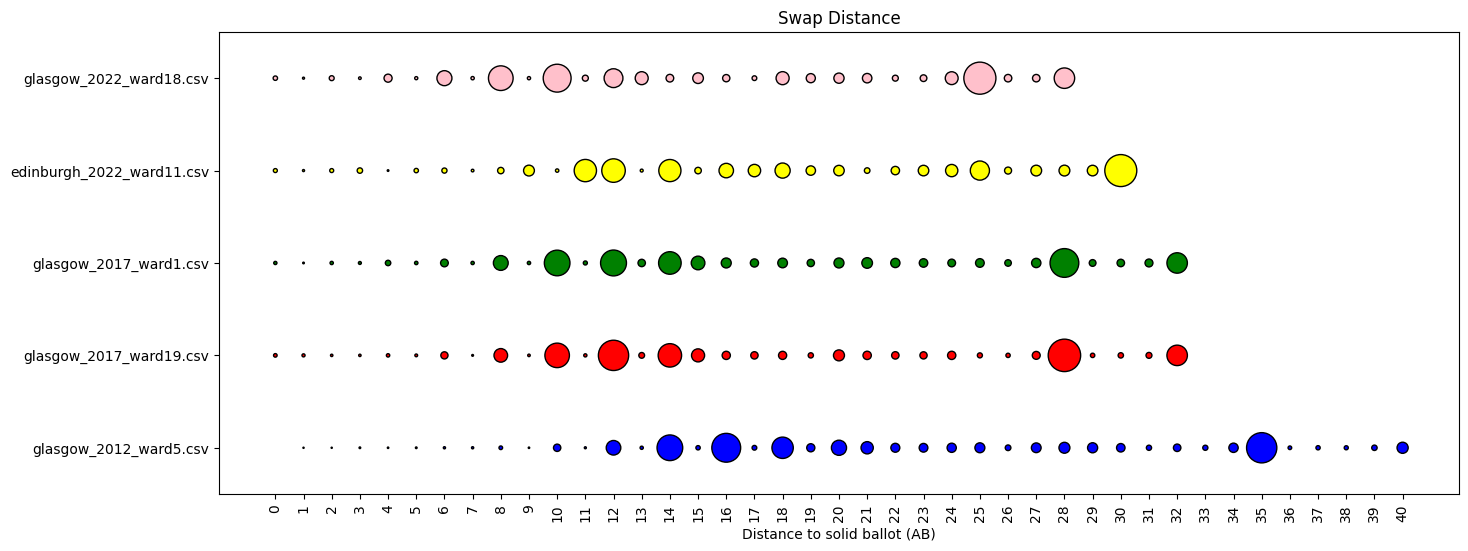

<Figure size 640x480 with 0 Axes>